# **Recurrent Neural Network**
Recurrent Neural Networks (RNNs) are a class of artificial neural networks designed to process sequential data (text, speech, time-series) by using hidden states to retain memory of previous inputs. Unlike feedforward networks, they use feedback loops to pass information across steps, making them ideal for natural language processing, translation, and forecasting.

![](https://media.geeksforgeeks.org/wp-content/uploads/20251215085936327384/recurrent_neural_network.webp)

## The Feedback Mechanism: The Hidden State
he defining feature of an RNN is the Hidden State ($h_{t}$). This is a vector that acts as a summary of everything the network has seen up to that point.

1. The Loop: At each time step $t$, the network takes two inputs: the current data point ($x_{t}$) and the hidden state from the previous step ($h_{t-1}$).
The
2. Calculation: It combines these two inputs to produce a new hidden state ($h_{t}$).
3. The Persistence: This new state is then passed forward to the next time step. Mathematically, it looks like this:

$$ h_{t} = f(W_{h}*h_{t-1} + W_{x}*x_{t}) $$

*(Where $f$ is an activation function like tanh or ReLU, and $W$ represents the weights the model learns.)*

![](https://media.geeksforgeeks.org/wp-content/uploads/20251215090232519391/nfa1.webp)

### In simple words:

- **Step 1**: The RNN receives the first word of a sentence. It creates a hidden state representing that word.
- Step 2: It receives the second word plus the hidden state from Step 1. It now knows the current word and its context (the previous word).
- Step 3: It receives the third word plus the updated hidden state from Step 2. This state now contains a compressed representation of the first two words.


## Embedding layer
The embedding layer is the very first step of the model when dealing with categorical or textual data. Its job is to transform discrete tokens—like words or IDs—into dense, continuous vectors that the network can actually process.

Instead of using "one-hot encoding" (which would create a massive vector of mostly zeros for every word), embeddings compress information into a much smaller, dense vector space (e.g., 50 to 300 dimensions).

> Similar to how word2vec was done by Google, not exactly similar but you can think of that as reference.

## Implementation

In [52]:
import tensorflow

In [53]:
# word embedding

from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential

In [54]:
from tensorflow.keras.datasets import imdb

In [55]:
voc_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=voc_size)

In [56]:
X_train.shape

(25000,)

### Padding Sequences

Since movie reviews have varying lengths, we need to pad them to a fixed `max_len`. This ensures all input sequences to the RNN have the same dimension. `padding='pre'` adds padding to the beginning of the sequences.

In [57]:
max_len = 500

X_train = pad_sequences(X_train, maxlen=max_len, padding='pre')
X_test = pad_sequences(X_test, maxlen=max_len, padding='pre')

In [58]:
model = Sequential()
model.add(Embedding(voc_size, 128, input_length=max_len))
model.add(SimpleRNN(128, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [64]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (32, 500, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 100)              │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 1)                │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,977,693 (15.17 MB)

 Trainable params: 1,325,897 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,651,796 (10.12 MB)

### Early Stopping Callback

To prevent overfitting and save training time, we use `EarlyStopping`. This callback monitors the validation loss and stops training if it doesn't improve for a specified number of epochs (`patience`). `restore_best_weights=True` ensures the model reverts to its best performing weights.

In [60]:
# early stopping

from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

### Training the Model

We train the model using the `fit` method, specifying the training data, number of epochs, validation split, batch size, and the early stopping callback.

In [61]:
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32, callbacks=early)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.5993 - loss: 4549.8350 - val_accuracy: 0.7454 - val_loss: 0.5118
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8295 - loss: 0.3958 - val_accuracy: 0.7700 - val_loss: 0.4741
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8980 - loss: 0.2649 - val_accuracy: 0.7958 - val_loss: 0.5026
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8653 - loss: 0.3057 - val_accuracy: 0.7474 - val_loss: 0.5979
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9430 - loss: 0.1513 - val_accuracy: 0.7944 - val_loss: 0.6481
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9680 - loss: 0.0965 - val_accuracy: 0.7790 - val_loss: 0.7652
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9733 - loss: 0.0744 - val_accuracy: 0.7348 - val_loss: 0.8275


In [62]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


### Model Evaluation

Finally, we evaluate the model's performance on the test set using `accuracy_score` and visualize the `confusion_matrix` to understand the types of correct and incorrect predictions made by the model.

0.77144


<Axes: >

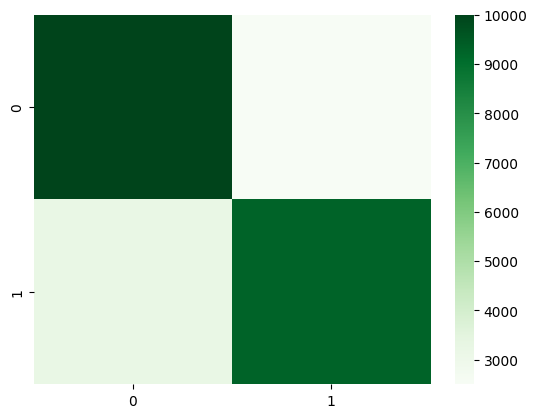

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

print(accuracy_score(y_pred=y_pred, y_true=y_test))
cm = confusion_matrix(y_pred=y_pred, y_true=y_test)
sns.heatmap(cm, cmap="Greens")